In [5]:
!pip install lifelines
from google.colab import files
uploaded = files.upload()

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 9.7 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=a92ace1d0e810ced6196bc2bfe16908e34e375c7fdc21a3c1afb25d1c58464d8
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


Saving TCGA.CESC.sampleMap_HiSeqV2.gz to TCGA.CESC.sampleMap_HiSeqV2.gz


In [6]:
!pip install lifelines
from google.colab import files
uploaded = files.upload()

Saving cesc_tcga_pan_can_atlas_2018_clinical_data.tsv to cesc_tcga_pan_can_atlas_2018_clinical_data.tsv


Please upload the `TCGA.CESC.sampleMap_HiSeqV2_exon.gz` and `YOUR_SURVIVAL_FILE_NAME.tsv` files using the 'Choose Files' button that appears after running the `files.upload()` command in the previous cell. If your survival file has a different name, please rename the placeholder `YOUR_SURVIVAL_FILE_NAME.tsv` in the code to match your uploaded file.

In [7]:
import pandas as pd

expr = pd.read_csv('TCGA.CESC.sampleMap_HiSeqV2.gz', sep='\t', index_col=0)
survival = pd.read_csv('cesc_tcga_pan_can_atlas_2018_clinical_data.tsv', sep='\t')  # adjust filename

print(expr.shape)
print(survival.shape)
print(survival.columns.tolist())
print(survival.head())

(20530, 308)
(297, 63)
['Study ID', 'Patient ID', 'Sample ID', 'Diagnosis Age', 'Neoplasm Disease Stage American Joint Committee on Cancer Code', 'American Joint Committee on Cancer Publication Version Type', 'Aneuploidy Score', 'Buffa Hypoxia Score', 'Cancer Type', 'TCGA PanCanAtlas Cancer Type Acronym', 'Cancer Type Detailed', 'Last Communication Contact from Initial Pathologic Diagnosis Date', 'Birth from Initial Pathologic Diagnosis Date', 'Last Alive Less Initial Pathologic Diagnosis Date Calculated Day Value', 'Disease Free (Months)', 'Disease Free Status', 'Months of disease-specific survival', 'Disease-specific Survival status', 'Ethnicity Category', 'Form completion date', 'Fraction Genome Altered', 'Genetic Ancestry Label', 'Neoplasm Histologic Grade', 'Neoadjuvant Therapy Type Administered Prior To Resection Text', 'ICD-10 Classification', 'International Classification of Diseases for Oncology, Third Edition ICD-O-3 Histology Code', 'International Classification of Diseases 

In [8]:
# Standardize sample IDs to 12-character patient ID
expr.columns = [c[:12] for c in expr.columns]
expr = expr.loc[:, ~expr.columns.duplicated()]

# Rename survival columns to something workable
survival = survival.rename(columns={
    'Patient ID': 'PATIENT_ID',
    'Overall Survival (Months)': 'OS_MONTHS',
    'Overall Survival Status': 'OS_STATUS_RAW'
})

# Convert status text ("0:LIVING" / "1:DECEASED") into 0/1
survival['OS_STATUS'] = survival['OS_STATUS_RAW'].str.startswith('1').astype(int)

# Drop rows missing survival time or status
survival = survival.dropna(subset=['OS_MONTHS', 'OS_STATUS'])

# Check overlap between expression samples and survival patients
common_ids = set(expr.columns) & set(survival['PATIENT_ID'])
print(f'Samples in expression data: {expr.shape[1]}')
print(f'Patients in survival data: {survival.shape[0]}')
print(f'Overlapping patients: {len(common_ids)}')

Samples in expression data: 303
Patients in survival data: 297
Overlapping patients: 292


In [9]:
genes_of_interest = ['TP53', 'PIK3CA', 'EGFR', 'VEGFA', 'MKI67']
genes_of_interest = [g for g in genes_of_interest if g in expr.index]
print('Genes found:', genes_of_interest)  # confirm none got dropped

gene_data = expr.loc[genes_of_interest].T
gene_data.index.name = 'PATIENT_ID'
gene_data = gene_data.reset_index()

merged = pd.merge(gene_data, survival[['PATIENT_ID', 'OS_MONTHS', 'OS_STATUS']], on='PATIENT_ID')
print(merged.shape)
merged.head()

Genes found: ['TP53', 'PIK3CA', 'EGFR', 'VEGFA', 'MKI67']
(292, 8)


,PATIENT_ID,TP53,PIK3CA,EGFR,VEGFA,MKI67,OS_MONTHS,OS_STATUS
0,TCGA-EA-A3HT,11.0781,9.8524,10.5049,12.8011,12.2550,31.364040,0
1,TCGA-FU-A3HZ,10.5041,7.9202,2.4563,11.5615,11.9636,36.262616,0
2,TCGA-FU-A3TQ,11.8542,8.5821,10.3896,12.8845,11.5903,26.136700,0
3,TCGA-DS-A0VK,11.6853,9.6076,11.7288,10.6309,11.2540,36.755762,1
4,TCGA-UC-A7PG,10.2973,9.3410,11.1209,12.9912,11.8121,12.164250,1


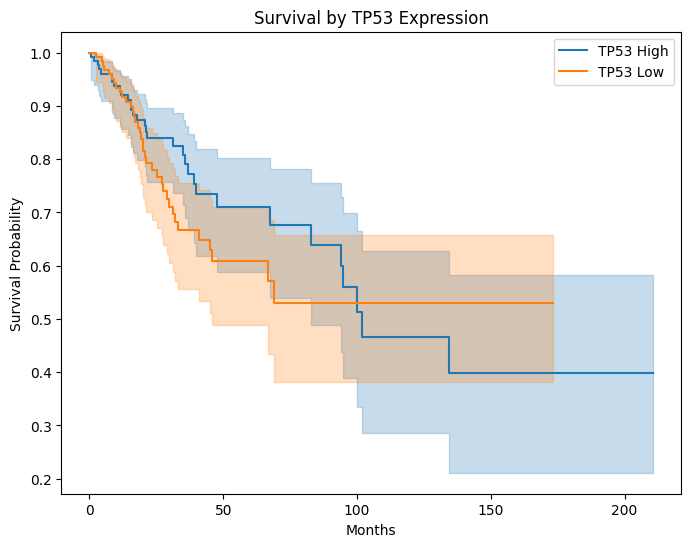

TP53 log-rank p-value: 0.3291


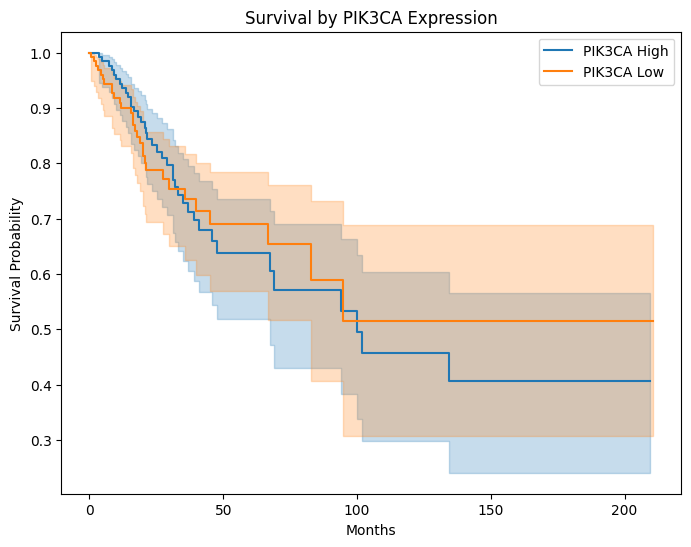

PIK3CA log-rank p-value: 0.9986


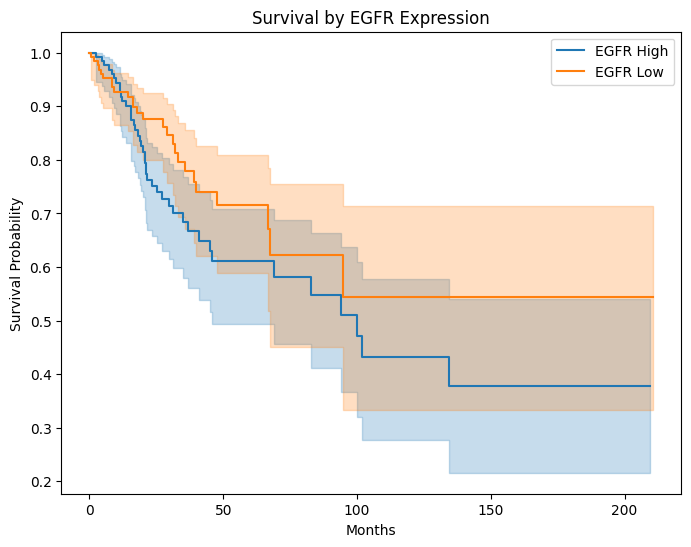

EGFR log-rank p-value: 0.1148


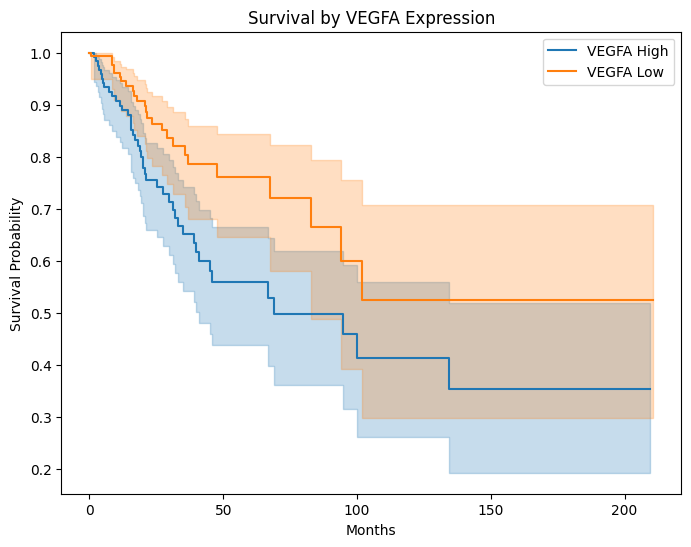

VEGFA log-rank p-value: 0.0080


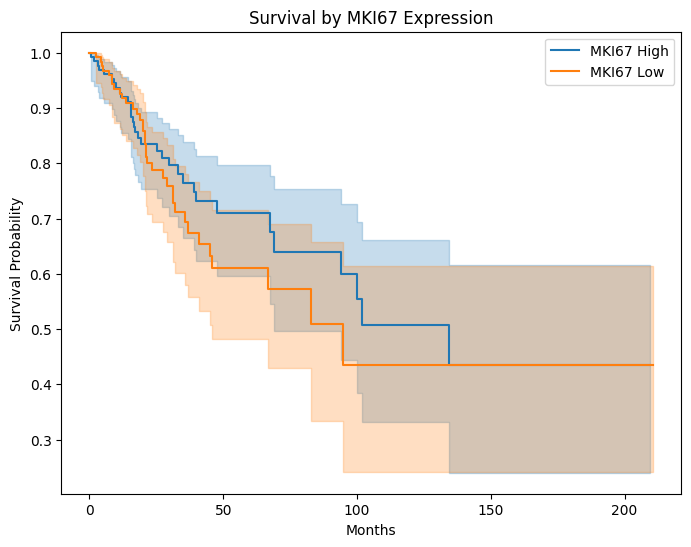

MKI67 log-rank p-value: 0.4394


In [10]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt

def plot_km(gene):
    median_expr = merged[gene].median()
    high = merged[merged[gene] > median_expr]
    low = merged[merged[gene] <= median_expr]

    kmf = KaplanMeierFitter()
    fig, ax = plt.subplots(figsize=(8,6))

    kmf.fit(high['OS_MONTHS'], high['OS_STATUS'], label=f'{gene} High')
    kmf.plot_survival_function(ax=ax)

    kmf.fit(low['OS_MONTHS'], low['OS_STATUS'], label=f'{gene} Low')
    kmf.plot_survival_function(ax=ax)

    plt.title(f'Survival by {gene} Expression')
    plt.xlabel('Months')
    plt.ylabel('Survival Probability')
    plt.savefig(f'{gene}_km_plot.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig) # Close the figure to free memory and ensure proper saving

    results = logrank_test(high['OS_MONTHS'], low['OS_MONTHS'],
                            high['OS_STATUS'], low['OS_STATUS'])
    print(f'{gene} log-rank p-value: {results.p_value:.4f}')

for gene in ['TP53', 'PIK3CA', 'EGFR', 'VEGFA', 'MKI67']:
    plot_km(gene)

<lifelines.CoxPHFitter: fitted with 292 total observations, 224 right-censored observations>
             duration col = 'OS_MONTHS'
                event col = 'OS_STATUS'
      baseline estimation = breslow
   number of observations = 292
number of events observed = 68
   partial log-likelihood = -316.47
         time fit was run = 2026-08-16 06:48:46 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
TP53      -0.32      0.73      0.20           -0.70            0.07                0.50                1.07
PIK3CA     0.01      1.01      0.19           -0.37            0.39                0.69                1.47
EGFR       0.19      1.21      0.10            0.00            0.38                1.00                1.46
VEGFA      0.43      1.54      0.13            0.17            0.70                1.19                2.01
MKI67     -0.21      0.81      0.18           -0.57            0.15                0.57                1.16

           cmp to     z      p  -log2(p)
covariate                               
TP53         0.00 -1.63   0.10      3.26
PIK3CA       0.00  0.06   0.96      0.07
EGFR         0.00  1.98   0.05      4.38
VEGFA        0.00  3.24 <0.005      9.73
MKI67        0.00 -1.13   0.26      1.96
---
Concordance = 0.65
Partial AIC = 642.94
log-likelihood ratio test = 20.59 on 5 df
-log2(p) of ll-ratio test = 10.01

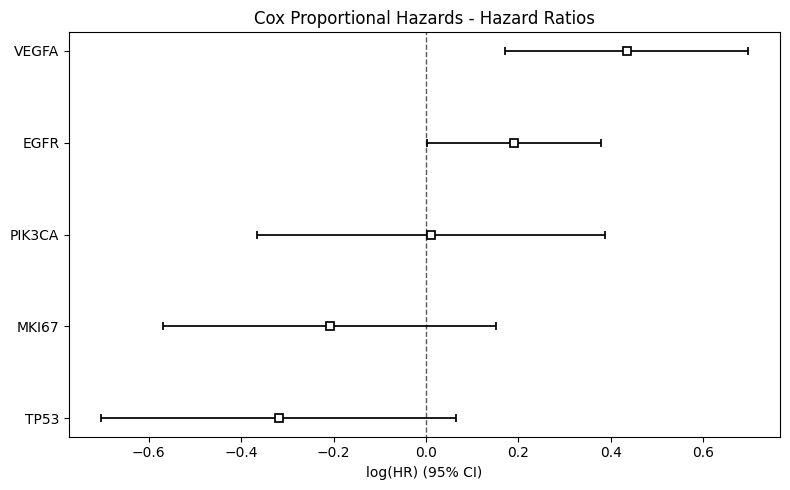

In [11]:
!pip install lifelines
from lifelines import CoxPHFitter

cox_data = merged[['TP53', 'PIK3CA', 'EGFR', 'VEGFA', 'MKI67', 'OS_MONTHS', 'OS_STATUS']].dropna()

cph = CoxPHFitter()
cph.fit(cox_data, duration_col='OS_MONTHS', event_col='OS_STATUS')
cph.print_summary()

plt.figure(figsize=(8,5))
cph.plot()
plt.title('Cox Proportional Hazards - Hazard Ratios')
plt.tight_layout()
plt.savefig('cox_forest_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
from google.colab import files
import zipfile

with zipfile.ZipFile('outputs.zip', 'w') as zf:
    for gene in ['TP53', 'PIK3CA', 'EGFR', 'VEGFA', 'MKI67']:
        zf.write(f'{gene}_km_plot.png')
    zf.write('cox_forest_plot.png')

files.download('outputs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>